# Diabetes - k-Nearest Neighbors

### Preliminary model

Using 50/50 set for training and imbalanced set for testing

In [26]:
#import tools and data for training and preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

diabetes_dataframe_training = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

diabetes_dataframe_training.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [27]:
# split the data into features and target variable

X_train = diabetes_dataframe_training.drop('Diabetes_binary', axis=1)
y_train = diabetes_dataframe_training['Diabetes_binary']

# train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# make predictions
diabetes_dataframe_testing = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

X_test = diabetes_dataframe_testing.drop('Diabetes_binary', axis=1)
y_test = diabetes_dataframe_testing['Diabetes_binary']

y_pred = knn.predict(X_test)

              precision    recall  f1-score   support

         0.0       0.74      0.85      0.79     35346
         1.0       0.82      0.70      0.76     35346

    accuracy                           0.77     70692
   macro avg       0.78      0.77      0.77     70692
weighted avg       0.78      0.77      0.77     70692



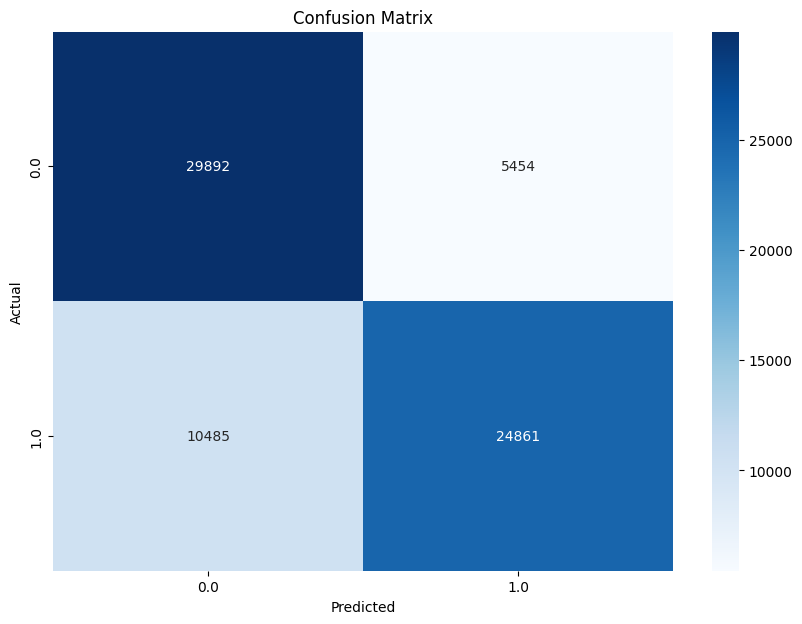

In [28]:
# evaluate the model
print(classification_report(y_test, y_pred))
# plot the confusion matrix

plt.figure(figsize=(10, 7))
sns.heatmap(pd.crosstab(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Modelling with pipelines

Using gridsearch and train_test_split to find optimal k-neighbours

In [29]:
# using 50/50 split and train test split
diabetes_dataframe = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

# split the data into features and target variable
X = diabetes_dataframe.drop('Diabetes_binary', axis=1)
y = diabetes_dataframe['Diabetes_binary']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# initialize pipeline
pipe = Pipeline([
    ('knn', KNeighborsClassifier())
])

# set up the parameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# initialize grid search
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# fit the model
grid.fit(X_train, y_train)

# best parameters
print("Best Parameters: ", grid.best_params_)
print("Best Cross-Validation Validation Score: ", grid.best_score_)

Best Parameters:  {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Best Cross-Validation Validation Score:  0.7225789203424036


              precision    recall  f1-score   support

         0.0       0.75      0.69      0.72      7090
         1.0       0.71      0.76      0.74      7049

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



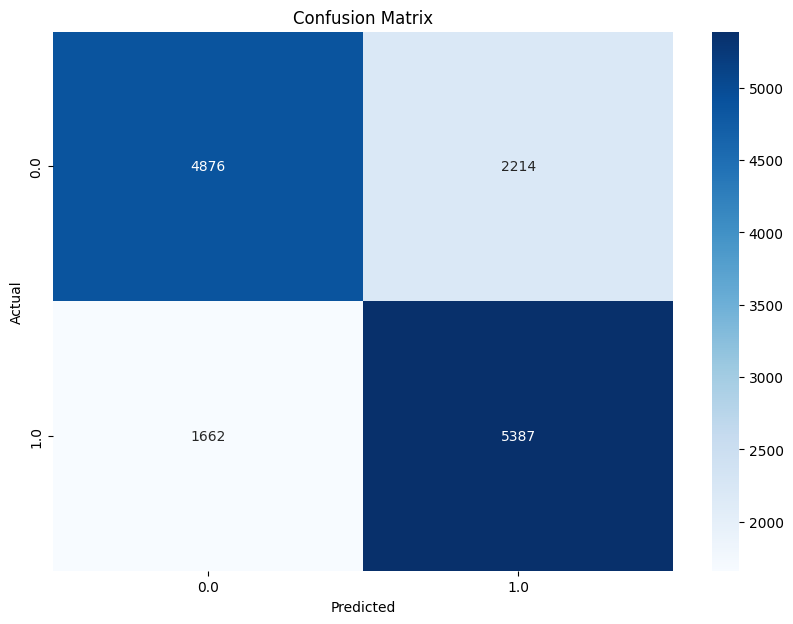

In [31]:
# make predictions
y_pred = grid.predict(X_test)

# evaluate the model
print(classification_report(y_test, y_pred))

# plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(pd.crosstab(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Seems the performance is a little worse on accuracy, perhaps splitting the already somewhat small 50/50 sample into testing/training sets lead to comparative underfitting.

So lets try pipelines again, but with the same data split strategy as in the first model made.

In [32]:
# split the trainging and testing data into features and target variable
X_train = diabetes_dataframe_training.drop('Diabetes_binary', axis=1)
y_train = diabetes_dataframe_training['Diabetes_binary']
X_test = diabetes_dataframe_testing.drop('Diabetes_binary', axis=1)
y_test = diabetes_dataframe_testing['Diabetes_binary']

Best Parameters:  {'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Best Cross-Validation Validation Score:  0.7040402540542068
              precision    recall  f1-score   support

         0.0       0.73      0.81      0.77     35346
         1.0       0.79      0.70      0.74     35346

    accuracy                           0.76     70692
   macro avg       0.76      0.76      0.76     70692
weighted avg       0.76      0.76      0.76     70692



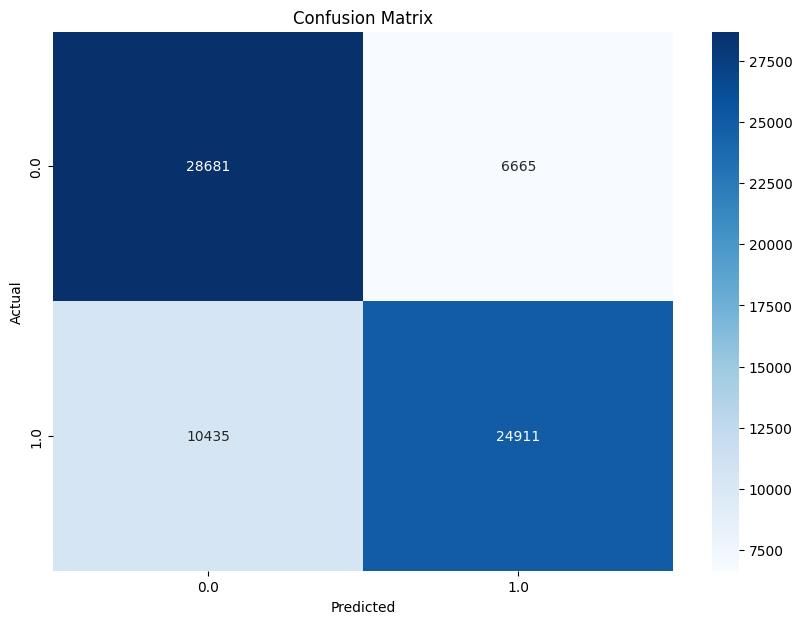

In [33]:
# we can use the same pipeline and grid search from before
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# fit the model
grid.fit(X_train, y_train)
# best parameters
print("Best Parameters: ", grid.best_params_)
print("Best Cross-Validation Validation Score: ", grid.best_score_)

# make predictions
y_pred = grid.predict(X_test)

# evaluate the model
print(classification_report(y_test, y_pred))

# plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(pd.crosstab(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()